# **언어 모델 활용_모델 Fine_Tuning_실습**

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [1]:
!pip install datasets peft accelerate -q

* 설치 후 세션 다시 시작

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

from peft import get_peft_model, LoraConfig, TaskType

from warnings import filterwarnings
FutureWarning
filterwarnings('ignore')

* 함수 생성

In [3]:
# 검증셋 평가 함수
def evaluate(val_ds, model, device, tokenizer):
    # 입력 데이터셋 토크나이징 (attention_mask 포함)
    inputs = tokenizer(list(val_ds['text']), return_tensors="pt", padding=True,
                       truncation=True, max_length=128
    )
    inputs = {key: value.to(device) for key, value in inputs.items()}  # 입력 텐서를 동일한 디바이스로 이동

    # 모델을 지정된 디바이스로 이동
    model = model.to(device)

    with torch.no_grad():  # 평가 과정에서 기울기 계산 비활성화
        outputs = model(**inputs)  # attention_mask를 포함해 입력

    # 예측 및 확률 계산
    probabilities = outputs.logits.softmax(dim=1)

    # probabilities가 GPU에 있을 경우에만 CPU로 이동
    if probabilities.is_cuda:
        probabilities = probabilities.cpu().detach().numpy()
    else:
        probabilities = probabilities.detach().numpy()

    pred = np.argmax(probabilities, axis=1)

    # GPU 메모리에서 필요 없는 텐서 제거 및 캐시 정리
    del inputs
    torch.cuda.empty_cache()

    return pred, probabilities

In [4]:
def predict(text, model, tokenizer):
    # 모델을 CPU로 이동
    model = model.to("cpu")

    # 입력 문장 토크나이징 → CPU 텐서로 생성
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # 모델 예측 (no_grad로 메모리 절약)
    with torch.no_grad():
        outputs = model(**inputs)

    # 확률 계산
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)

    # 예측 클래스
    pred = torch.argmax(probabilities, dim=-1).item()

    return pred, probabilities


### (2) 구글드라이브 연결

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
path = '/content/drive/MyDrive/langchain/'

### (3) 데이터 로딩

In [7]:
data = pd.read_csv('https://raw.githubusercontent.com/DA4BAM/dataset/refs/heads/master/naver_news_title.csv')
data.rename(columns = {'titles' : 'text', 'category' : 'label'}, inplace = True)
data.drop_duplicates(subset=['text'], inplace=True)
data = data.sample(5000)
data.head()

,text,label
24040,마켓인 산은 덕에 라이브시티 자금 숨통 장기 발행,Economic
1679,현장 사라진 해조류 북상하는 소라,Social
50643,지구촌 돋보기 한국 반도체 잡겠다며 토요타 소니 뭉쳤다 파급력은,World
1784,단독 화장품 광고 속 피부과 의사 알고 보니 배우 리포트,Social
393,전액 장학금에 졸업 조건이 창업 이 대학 한국서 통할까,Social


* y 분포 확인하기

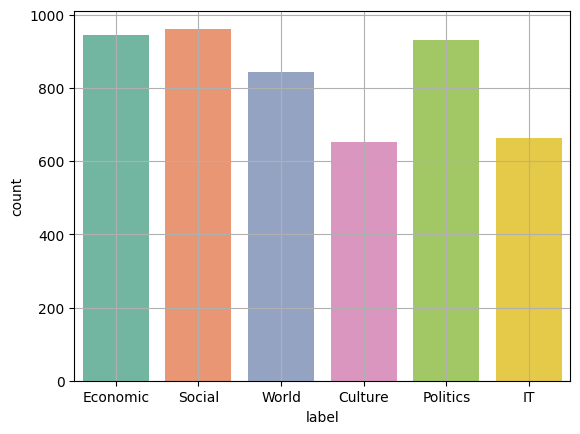

In [8]:
sns.countplot(x='label', data = data, palette='Set2')
plt.grid()
plt.show()

* label 에 대한 정수 인코딩

In [9]:
le = LabelEncoder()
data['label'] = le.fit_transform(data['label'])
data.head()

,text,label
24040,마켓인 산은 덕에 라이브시티 자금 숨통 장기 발행,1
1679,현장 사라진 해조류 북상하는 소라,4
50643,지구촌 돋보기 한국 반도체 잡겠다며 토요타 소니 뭉쳤다 파급력은,5
1784,단독 화장품 광고 속 피부과 의사 알고 보니 배우 리포트,4
393,전액 장학금에 졸업 조건이 창업 이 대학 한국서 통할까,4


In [10]:
label_list = list(le.classes_)
label_list

['Culture', 'Economic', 'IT', 'Politics', 'Social', 'World']

### (4) GPU 설정
* 파이토치를 위한 설정

In [11]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.데이터 준비

### (1) Dataset 만들기 : train, val

In [12]:
train, val = train_test_split(data, test_size=0.3, random_state=10)

In [13]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

In [14]:
train_ts[:3]

{'text': ['사우디  아르헨 꺾고 대이변       안정환 김성주 월드컵 중계 또  위',
  '주호영  화물연대  답 정해진 정치파업 모든 법적 책임져야 ',
  '기아차 근로자들   통상임금   차 소송 승소          억 지급 '],
 'label': [5, 3, 4],
 '__index_level_0__': [50953, 20418, 730]}

### (2) 토크나이징

In [15]:
# 모델과 토크나이저 불러오기
model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [16]:
# 토큰화 함수 생성 및 작업
def preprocess_function(data):
    return tokenizer(data['text'], truncation=True, padding=True)

train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

Map:   0%|          | 0/3500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

In [17]:
train_ts[0]

{'text': '사우디  아르헨 꺾고 대이변       안정환 김성주 월드컵 중계 또  위',
 'label': 5,
 '__index_level_0__': 50953,
 'input_ids': [2,
  13713,
  5996,
  2727,
  667,
  2088,
  823,
  2052,
  2447,
  4262,
  2018,
  6576,
  2223,
  5339,
  8137,
  918,
  1485,
  3,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'token_type_ids': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0]}

## 3.Fine-Tuning

### (1) 사전학습 모델 준비

In [18]:
# 1. 모델 로드
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6)

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) 학습 설정

In [19]:
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to="tensorboard"
)

In [20]:
# Trainer 설정
trainer = Trainer(
    model=model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

### (3) 학습
* 위 코드 그대로

In [21]:
# 모델 학습
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.912000,0.794521
2,0.578500,0.729116
3,0.437600,0.713932
4,0.314800,0.721113
5,0.266100,0.732206


TrainOutput(global_step=550, training_loss=0.5879113383726641, metrics={'train_runtime': 201.4756, 'train_samples_per_second': 86.859, 'train_steps_per_second': 2.73, 'total_flos': 323673166635408.0, 'train_loss': 0.5879113383726641, 'epoch': 5.0})

In [22]:
# 모델 평가
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Evaluation results: {'eval_loss': 0.7139315009117126, 'eval_runtime': 2.6938, 'eval_samples_per_second': 556.825, 'eval_steps_per_second': 17.447, 'epoch': 5.0}


### (4) 모델 사용

In [23]:
text = "파인튜닝 모델을 이용해서 저비용 고성능 모델 개발"
predicted_class, probabilities = predict(text, model, tokenizer)

print(f"예측된 클래스: {predicted_class}")
print(f"예측된 클래스 이름: {label_list[predicted_class]}")
print(f"클래스별 확률: {probabilities}")

예측된 클래스: 1
예측된 클래스 이름: Economic
클래스별 확률: tensor([[0.0827, 0.4647, 0.4326, 0.0045, 0.0055, 0.0100]])


### (5) 모델 검증평가

In [24]:
pred, prob = evaluate(val_ts, model, device, tokenizer)

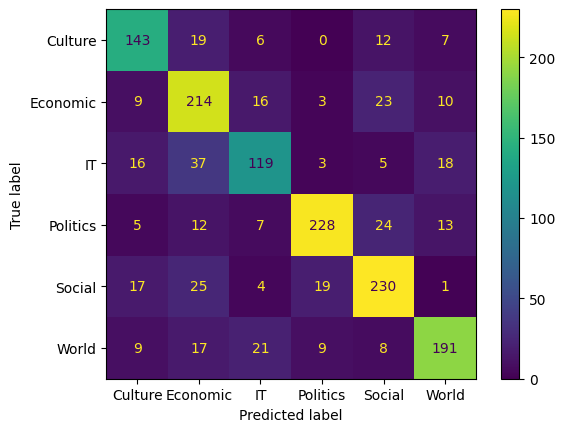

              precision    recall  f1-score   support

     Culture       0.72      0.76      0.74       187
    Economic       0.66      0.78      0.71       275
          IT       0.69      0.60      0.64       198
    Politics       0.87      0.79      0.83       289
      Social       0.76      0.78      0.77       296
       World       0.80      0.75      0.77       255

    accuracy                           0.75      1500
   macro avg       0.75      0.74      0.74      1500
weighted avg       0.75      0.75      0.75      1500



In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(val_ts['label'], pred), display_labels = label_list)
disp.plot()
plt.show()

print(classification_report(val_ts['label'], pred, target_names = label_list))